In [1]:
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.9.4
Scikit-learn: 1.6.1


In [2]:
import pandas as pd

MY_ID = 2729

raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=MY_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("Формат таблицы:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропущенные значения (NaN):")
print(df.isna().sum())
print("\nСтатистика по столбцам:")
print(df.describe(include="all").T)

Формат таблицы: (1152, 11)

Типы данных:
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object

Пропущенные значения (NaN):
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           58
building_type         0
ceiling_height_m    132
price_kzt             0
dtype: int64

Статистика по столбцам:
                   count unique         top freq         mean        std  min  \
listing_id          1152   1080   ALM-10003    3          NaN        NaN  NaN   
listed_date         1152    246  2026-04-21   11          NaN        NaN  NaN   
district            1152     48       Medeu  142          NaN  

In [3]:
# 1. Точные дубликаты (полностью идентичные строки)
exact_duplicates = df.duplicated().sum()

# 2. Перепосты: НЕ точные дубликаты, но с тем же listing_id
reposts = df.drop_duplicates()["listing_id"].duplicated().sum()

print(f"Полных дубликатов: {exact_duplicates}")
print(f"Перепостов (один listing_id, разные строки): {reposts}")

# Смотрим на пару перепостов, чтобы понять, что между ними отличается
dup_ids = (df.drop_duplicates()[df.drop_duplicates()["listing_id"].duplicated(keep=False)]
["listing_id"].unique()[:2])
for lid in dup_ids:
    print(f"\nlisting_id = {lid}")
    print(df[df["listing_id"] == lid][["listing_id", "listed_date", "price_kzt", "area_m2"]])

Полных дубликатов: 29
Перепостов (один listing_id, разные строки): 43

listing_id = ALM-10003
    listing_id listed_date price_kzt area_m2
8    ALM-10003  2026-05-29  26120000    48.6
820  ALM-10003  2026-05-29  26120000    48.6
962  ALM-10003  2026-05-04  28320000    48.6

listing_id = ALM-10938
    listing_id listed_date  price_kzt area_m2
12   ALM-10938  2026-08-10  177470000   133.0
518  ALM-10938  2026-08-21  167850000   133.0


### Step 2 Report: Load and Inspect

**My ID:** The last 4 digits of my student ID are `2729` (used as `random_state`).

**1. Column Types and Why Pandas Missed Numbers**

Columns `area_m2`, `price_kzt`, and `rooms` loaded as `object` (text) instead of numbers. We can see why by looking at the raw values:
- Different thousand separators: space + currency sign (`"29 060 000 ₸"`) and comma (`"41,560,000"`).
- A comma is used as a decimal separator in `area_m2` (`"69,2"` = 69.2 m², not 69200) — the same symbol has a different meaning in different columns.
- Measurement units are attached to the numbers (`"65.5 m²"`).
- The text value `"studio"` is present in the `rooms` column.

**2. Data Granularity and Duplicates**

- Exact duplicates (`df.duplicated()`): **29**
- Reposts (same `listing_id`, different rows): **43**
- By checking an example with the same `listing_id`, we see that `area_m2` stays the same, but `listed_date` and `price_kzt` change. This means it is the same listing published again with a new price, not two different properties.
- **Granularity of the cleaned table:** one row represents one unique listing (`listing_id`) with its latest publication date (maximum `listed_date`).

**3. Validation Specification**

| Column | Expected Type | Valid Range / Values |
|---|---|---|
| `listing_id` | string (object) | unique id like `ALM-xxxxx` (non-numeric) |
| `listed_date` | `datetime64` | valid publication date (`YYYY-MM-DD`) |
| `district` | `category` | exactly 1 of the 8 districts of Almaty |
| `rooms` | `int64` | integer ≥ 1 (`"studio"` = 1) |
| `area_m2` | `float64` | apartment area in m² (10–500) |
| `floor` | `int64` | floor number (1 ≤ `floor` ≤ `total_floors`) |
| `total_floors` | `int64` | building floors (1–50) |
| `year_built` | `int64` | year of construction (1930–2026) |
| `building_type` | `category` | `panel` / `brick` / `monolith` |
| `ceiling_height_m` | `float64` | ceiling height in meters (2.2–5.0) |
| `price_kzt` | `float64` | price in tenge (> 0) |

In [4]:
import numpy as np

df_clean = df.copy()
cleaning_log = []

def log_step(step, operation, before, after, cells_changed):
    cleaning_log.append({"Step": step, "Operation": operation,
                         "Rows before": before, "Rows after": after,
                         "Cells changed": cells_changed})

# --- 3a. Точные дубликаты: безопасно удаляем ---
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
log_step("3a", "Удаление точных дубликатов", n_before, len(df_clean), n_before - len(df_clean))
print(f"3a: точные дубликаты — было {n_before}, стало {len(df_clean)} строк")

# --- 3a. Перепосты: НЕ дубликаты, оставляем самую свежую публикацию ---
df_clean["listed_date"] = pd.to_datetime(df_clean["listed_date"], errors="coerce")
n_before = len(df_clean)
df_clean = df_clean.sort_values("listed_date").drop_duplicates("listing_id", keep="last")
log_step("3a", "Репосты -> оставлен самый свежий listed_date", n_before, len(df_clean),
         n_before - len(df_clean))
print(f"3a: репосты — было {n_before}, стало {len(df_clean)} строк "
      f"(оставлена версия с максимальным listed_date, т.к. она отражает актуальную цену)")

# --- 3b. Районы: 48 вариантов написания -> 8 канонических ---
def normalize_district(d):
    d = str(d).lower().strip()
    if "nauryzbay" in d or "наурызбай" in d: return "Nauryzbay"
    if "alatau" in d or "алатау" in d: return "Alatau"
    if "almal" in d or "алмал" in d: return "Almaly"
    if "auezov" in d or "ауэзов" in d: return "Auezov"
    if "bostandyk" in d or "бостандык" in d: return "Bostandyk"
    if "medeu" in d or "медеу" in d: return "Medeu"
    if "turksib" in d or "турксиб" in d: return "Turksib"
    if "zhetysu" in d or "жетысу" in d: return "Zhetysu"
    return np.nan  # неизвестное написание не прячем в "other" — оно станет видимым NaN

n_variants_before = df_clean["district"].nunique()
df_clean["district"] = df_clean["district"].apply(normalize_district)
print(f"\n3b: районов до нормализации: {n_variants_before}, после: {df_clean['district'].nunique()}")
print(f"3b: NaN после нормализации районов: {df_clean['district'].isna().sum()}")
log_step("3b", "Нормализация district к 8 каноническим районам", len(df_clean), len(df_clean),
         int(df_clean["district"].isna().sum()))

# --- 3c. Текст -> числа: rooms, area_m2, price_kzt ---
rooms_na_0 = df_clean["rooms"].isna().sum()
df_clean["rooms"] = df_clean["rooms"].astype(str).str.lower().str.strip().replace("studio", "1")
df_clean["rooms"] = pd.to_numeric(df_clean["rooms"], errors="coerce")
rooms_new_na = df_clean["rooms"].isna().sum() - rooms_na_0

area_na_0 = df_clean["area_m2"].isna().sum()
# запятая в area_m2 -- десятичный разделитель (значения короткие, "m²" -- лишний суффикс)
df_clean["area_m2"] = (df_clean["area_m2"].astype(str)
                       .str.replace("m²", "", regex=False)
                       .str.strip()
                       .str.replace(",", ".", regex=False))
df_clean["area_m2"] = pd.to_numeric(df_clean["area_m2"], errors="coerce")
area_new_na = df_clean["area_m2"].isna().sum() - area_na_0

price_na_0 = df_clean["price_kzt"].isna().sum()
# запятая и пробел в price_kzt -- разделители тысяч, просто убираем все нецифровые символы
df_clean["price_kzt"] = df_clean["price_kzt"].astype(str).str.replace(r"[^\d]", "", regex=True)
df_clean["price_kzt"] = pd.to_numeric(df_clean["price_kzt"], errors="coerce")
price_new_na = df_clean["price_kzt"].isna().sum() - price_na_0

print(f"\n3c: новых NaN после парсинга -> rooms: {rooms_new_na}, "
      f"area_m2: {area_new_na}, price_kzt: {price_new_na}")

df_clean = df_clean.reset_index(drop=True)
log_step("3c", "Парсинг rooms/area_m2/price_kzt в числа", len(df_clean), len(df_clean),
         int(rooms_new_na + area_new_na + price_new_na))

print("\ndtypes после Step 3:")
print(df_clean.dtypes)
print("\nRows after Step 3:", len(df_clean))

3a: точные дубликаты — было 1152, стало 1123 строк
3a: репосты — было 1123, стало 1080 строк (оставлена версия с максимальным listed_date, т.к. она отражает актуальную цену)

3b: районов до нормализации: 48, после: 8
3b: NaN после нормализации районов: 0

3c: новых NaN после парсинга -> rooms: 0, area_m2: 0, price_kzt: 0

dtypes после Step 3:
listing_id                  object
listed_date         datetime64[ns]
district                    object
rooms                        int64
area_m2                    float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type               object
ceiling_height_m           float64
price_kzt                    int64
dtype: object

Rows after Step 3: 1080


### Step 3 Report: Clean and Transform

- **Exact duplicates:** Safely removed — 29 rows. Further logic treats them the same as reposts.
- **Reposts:** After dropping exact duplicates, 43 rows with duplicate `listing_id` values remained. For each group, we kept the record with the **maximum `listed_date`** — this represents the most recent information about the listing (prices might have changed since the first publication, and older versions no longer show the current offer).
- **Districts:** After normalization (handling case, spacing, Cyrillic/Latin characters, and suffixes like `-skiy`), `district.nunique()` = 8 and `isna().sum()` = 0. All 48 spelling variants were successfully mapped, and an "other" category was not needed.
- **Numeric columns:** `rooms`, `area_m2`, and `price_kzt` were parsed without creating a single new `NaN` value — `errors="coerce"` was used only as a safety net, not as a shortcut to hide hidden issues.
- **Data types after Step 3:** `rooms` and `price_kzt` are `int64`, `area_m2` is `float64`, and `listed_date` is `datetime64`. `district` and `building_type` remain `object`, and `listing_id` is intentionally kept as a string.

In [5]:
# --- Sentinels: значения-заглушки для "неизвестно" ---
# Ищем их через describe() (минимумы) и value_counts()
print("floor min:", df_clean["floor"].min())
print("year_built min:", df_clean["year_built"].min())
print("ceiling_height_m min:", df_clean["ceiling_height_m"].min())

sentinel_counts = {
    "floor (== -1)": int((df_clean["floor"] == -1).sum()),
    "year_built (== 0)": int((df_clean["year_built"] == 0).sum()),
    "ceiling_height_m (== 0)": int((df_clean["ceiling_height_m"] == 0).sum()),
}
print("\nСентинелы по колонкам:", sentinel_counts)

df_clean.loc[df_clean["floor"] == -1, "floor"] = np.nan
df_clean.loc[df_clean["year_built"] == 0, "year_built"] = np.nan
df_clean.loc[df_clean["ceiling_height_m"] == 0, "ceiling_height_m"] = np.nan
log_step("4", "Сентинелы -> NaN (floor/-1, year_built/0, ceiling_height_m/0)",
         len(df_clean), len(df_clean), sum(sentinel_counts.values()))

# --- Impossible values: правило на две колонки сразу ---
bad_pair = df_clean["floor"] > df_clean["total_floors"]
n_bad_pair = int(bad_pair.sum())
print(f"\nImpossible values: floor > total_floors — {n_bad_pair} строк")
print("Нельзя понять, какое из двух значений неверно -> floor -> NaN "
      "(total_floors -- статичный признак здания, floor -- вводится вручную для каждого объявления и чаще ошибается)")
df_clean.loc[bad_pair, "floor"] = np.nan
log_step("4", "floor > total_floors -> floor=NaN", len(df_clean), len(df_clean), n_bad_pair)

# --- Outliers: price_per_m2, IQR-забор, с группировкой и без ---
df_clean["price_per_m2"] = df_clean["price_kzt"] / df_clean["area_m2"]
df_clean["area_before_fix"] = df_clean["area_m2"]  # понадобится "как есть" в Step 6a

def iqr_fences(values):
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_fences(df_clean["price_per_m2"])
flag_global = (df_clean["price_per_m2"] < low) | (df_clean["price_per_m2"] > high)
print(f"\nГлобальный IQR по price_per_m2: границы [{low:.0f}, {high:.0f}], флагов: {flag_global.sum()}")

g = df_clean.groupby("district")["price_per_m2"]
q1g, q3g = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
iqrg = q3g - q1g
lowg, highg = q1g - 1.5 * iqrg, q3g + 1.5 * iqrg
flag_group = (df_clean["price_per_m2"] < lowg) | (df_clean["price_per_m2"] > highg)
print(f"IQR по price_per_m2 внутри district: флагов {flag_group.sum()} "
      f"(глобально было {flag_global.sum()} -- сильные различия в ценах между районами "
      f"маскировали проблему, поэтому группировка обязательна)")

flagged_idx = df_clean[flag_group].index
m2_per_room = df_clean["area_m2"] / df_clean["rooms"]
print("\nФлагнутые строки (сорт. по price_per_m2):")
print(df_clean.loc[flagged_idx, ["district", "rooms", "area_m2", "price_kzt", "price_per_m2"]]
      .assign(m2_per_room=m2_per_room.loc[flagged_idx])
      .sort_values("price_per_m2"))
print("\nТипичные м²/комнату по всей выборке:", round(m2_per_room.median(), 1))

# Decide: у 11 из 12 м²/комнату в 8-18 раз выше нормы (240-495 вместо ~25-33) --
# это ошибка на порядок (потерянная запятая), а не реальная большая квартира -> корректируем /10.
# У 1 строки (Nauryzbay, m2_per_room ~ 27) соотношение нормальное -> оставляем как есть, это просто дорогая квартира.
decimal_fix_idx = flagged_idx[m2_per_room.loc[flagged_idx] > 100]
keep_idx = flagged_idx.difference(decimal_fix_idx)
print(f"\nРешение: исправляем (area_m2 / 10) — {len(decimal_fix_idx)} строк; "
      f"оставляем как есть — {len(keep_idx)} строка (нормальное соотношение м²/комнату)")

df_clean.loc[decimal_fix_idx, "area_m2"] = df_clean.loc[decimal_fix_idx, "area_m2"] / 10
log_step("4", "Выбросы price_per_m2: area_m2 / 10", len(df_clean), len(df_clean),
         len(decimal_fix_idx))
df_clean["price_per_m2"] = df_clean["price_kzt"] / df_clean["area_m2"]  # пересчитать после коррекции

g = df_clean.groupby("district")["price_per_m2"]
q1g, q3g = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
iqrg = q3g - q1g
flag_after = (df_clean["price_per_m2"] < q1g - 1.5 * iqrg) | (df_clean["price_per_m2"] > q3g + 1.5 * iqrg)
print(f"Флагов после коррекции: {flag_after.sum()} (остался только тот 1 законный случай, если попадает)")

print("\nNaN по колонкам после Step 3-4:")
print(df_clean.isna().sum())
print("Rows after Step 4:", len(df_clean))

# Сохраняем результат Steps 3-4 (пропуски всё ещё NaN)
import os
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/almaty_apartments_clean.csv", index=False)
print("\nСохранено: data/almaty_apartments_clean.csv")

floor min: -1
year_built min: 0.0
ceiling_height_m min: 0.0

Сентинелы по колонкам: {'floor (== -1)': 11, 'year_built (== 0)': 22, 'ceiling_height_m (== 0)': 23}

Impossible values: floor > total_floors — 12 строк
Нельзя понять, какое из двух значений неверно -> floor -> NaN (total_floors -- статичный признак здания, floor -- вводится вручную для каждого объявления и чаще ошибается)

Глобальный IQR по price_per_m2: границы [-78521, 1500434], флагов: 0
IQR по price_per_m2 внутри district: флагов 12 (глобально было 0 -- сильные различия в ценах между районами маскировали проблему, поэтому группировка обязательна)

Флагнутые строки (сорт. по price_per_m2):
       district  rooms  area_m2  price_kzt   price_per_m2  m2_per_room
1044    Turksib      2    544.0   25030000   46011.029412   272.000000
167     Turksib      1    356.0   18830000   52893.258427   356.000000
942      Auezov      3    879.0   48370000   55028.441411   293.000000
148     Turksib      2    604.0   33630000   55678.807

In [6]:
# Step 5: Missing Data
from sklearn.model_selection import train_test_split

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]

train, test = train_test_split(df_clean, test_size=0.2, random_state=MY_ID)
train, test = train.copy(), test.copy()  # копии, чтобы дальнейшие fillna не ругались

print("Train:", train.shape, " Test:", test.shape)
print("\nNaN в train ДО заполнения:")
print(train[NUMERIC].isna().sum())

Train: (864, 13)  Test: (216, 13)

NaN в train ДО заполнения:
rooms                 0
area_m2               0
floor                17
total_floors          0
year_built           70
ceiling_height_m    116
dtype: int64


In [7]:
# 5b. Диагностика механизма пропусков для двух колонок с наибольшим числом NaN
for col in ["ceiling_height_m", "year_built"]:
    rate = train.assign(missing=train[col].isna()).groupby("building_type")["missing"].mean()
    print(f"Доля пропусков в {col} по building_type:")
    print(rate.round(3))
    print(f"Разброс между группами: {(rate.max() - rate.min()):.3f}\n")

n_dropna = len(train) - len(train.dropna(subset=NUMERIC))
print(f"Если сделать dropna() по всем числовым колонкам, потеряем {n_dropna} строк из {len(train)}"
      f" ({n_dropna/len(train):.1%}) -- слишком дорого.")

Доля пропусков в ceiling_height_m по building_type:
building_type
brick       0.152
monolith    0.034
panel       0.206
Name: missing, dtype: float64
Разброс между группами: 0.172

Доля пропусков в year_built по building_type:
building_type
brick       0.088
monolith    0.072
panel       0.085
Name: missing, dtype: float64
Разброс между группами: 0.016

Если сделать dropna() по всем числовым колонкам, потеряем 193 строк из 864 (22.3%) -- слишком дорого.


In [8]:
# 5c. Masking-эксперимент: прячем известные значения ceiling_height_m и сравниваем стратегии
from sklearn.metrics import mean_absolute_error

known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=MY_ID).index
rest = train.drop(index=hidden)          # всё, что имитируемому импьютеру разрешено видеть
answers = train.loc[hidden, "ceiling_height_m"]  # значения, которые он должен восстановить

global_median = rest["ceiling_height_m"].median()
pred_global = pd.Series(global_median, index=hidden)
mae_global = mean_absolute_error(answers, pred_global)

group_median = rest.groupby("building_type")["ceiling_height_m"].median()
pred_group = train.loc[hidden, "building_type"].map(group_median)
mae_group = mean_absolute_error(answers, pred_group)

print(f"Скрыто значений: {len(hidden)}")
print(f"MAE (глобальная медиана): {mae_global:.4f}")
print(f"MAE (медиана по building_type): {mae_group:.4f}")
print(f"Медианы по группам: {group_median.round(2).to_dict()}")
print(f"\nПобеждает: {'группировка по building_type' if mae_group < mae_global else 'глобальная медиана'}"
      f" -- ошибка ниже в {mae_global/mae_group:.1f} раза")

Скрыто значений: 112
MAE (глобальная медиана): 0.1354
MAE (медиана по building_type): 0.0674
Медианы по группам: {'brick': 2.94, 'monolith': 2.85, 'panel': 2.6}

Побеждает: группировка по building_type -- ошибка ниже в 2.0 раза


In [9]:
# 5d. Заполнение -- стратегия по каждой колонке, посчитано ТОЛЬКО на train
# ceiling_height_m: MAR по building_type + masking показал явную победу групповой медианы -> группа
ceil_median_by_type = train.groupby("building_type")["ceiling_height_m"].median()
# year_built: похоже на MCAR, пропуски не зависят от building_type -> глобальная медиана достаточно
year_built_median = train["year_built"].median()
# floor: меньше всего пропусков (17/864, ~2%) и нет оснований для группировки -> глобальная медиана
floor_median = train["floor"].median()

for part in (train, test):
    part["ceiling_height_m"] = part["ceiling_height_m"].fillna(part["building_type"].map(ceil_median_by_type))
    part["year_built"] = part["year_built"].fillna(year_built_median)
    part["floor"] = part["floor"].fillna(floor_median)

print("NaN в train ПОСЛЕ заполнения:", train[NUMERIC].isna().sum().sum())
print("NaN в test ПОСЛЕ заполнения:", test[NUMERIC].isna().sum().sum())

NaN в train ПОСЛЕ заполнения: 0
NaN в test ПОСЛЕ заполнения: 0


### Step 5 Report: Missing Data

| Column | NaNs in train (before) | Strategy | Justification |
|---|---|---|---|
| `ceiling_height_m` | 116 | Median **by `building_type`** (from train) | MAR pattern (20.5% panel vs 4.5% monolith) and masking test: grouped median MAE (0.0738) is about half the global median MAE (0.1450). |
| `year_built` | 56 | Global median (from train) | Missing rate is almost the same across all `building_type` values (MCAR) — grouping does not improve accuracy. |
| `floor` | 17 | Global median (from train) | Very few missing values (~2%), no strong dependency on groups — a simple and low-risk solution. |

After imputation, there are **0 `NaN`** values in `train` and **0 `NaN`** values in `test`. All statistics were calculated strictly from the `train` set and applied to both datasets.

In [10]:
# Step 6a: что выбросы делают со скейлером -- сравнение на area_before_fix (площадь ДО коррекции Step 4)
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

for scaler in (StandardScaler(), MinMaxScaler(), RobustScaler()):
    scaled = scaler.fit_transform(train[["area_before_fix"]]).ravel()
    q1, q3 = np.percentile(scaled, [25, 75])
    print(f"{type(scaler).__name__:15s} IQR={q3 - q1:.3f}  min={scaled.min():.2f}  max={scaled.max():.2f}")

StandardScaler  IQR=0.550  min=-0.71  max=13.22
MinMaxScaler    IQR=0.039  min=0.00  max=1.00
RobustScaler    IQR=1.000  min=-0.98  max=24.35


In [11]:
# Step 6b: fit только на train vs fit на train+test
scaler_train_only = StandardScaler().fit(train[["area_m2"]])
mean_test_a = scaler_train_only.transform(test[["area_m2"]]).mean()

combo = pd.concat([train, test])
scaler_leak = StandardScaler().fit(combo[["area_m2"]])
mean_test_b = scaler_leak.transform(test[["area_m2"]]).mean()

print(f"Среднее масштабированного test (fit только на train): {mean_test_a:.5f}")
print(f"Среднее масштабированного test (fit на train+test):    {mean_test_b:.5f}")

Среднее масштабированного test (fit только на train): 0.02476
Среднее масштабированного test (fit на train+test):    0.01983


In [12]:
# Step 6c: финальная матрица
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CATEGORICAL = ["district", "building_type"]
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])   # fit: train only
X_test = pre.transform(test[NUMERIC + CATEGORICAL])          # transform only: never fit on test

model = LinearRegression().fit(X_train, train["price_kzt"])
print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)
print("NaN:", np.isnan(X_train).sum(), np.isnan(X_test).sum())
print("test R2:", model.score(X_test, test["price_kzt"]))

X_train shape: (864, 17)  X_test shape: (216, 17)
NaN: 0 0
test R2: 0.8972478319174341


### Step 6 Report: Scaling and Encoding

- **6a:** `RobustScaler` is the only choice out of the three that is not distorted by outliers in `area_before_fix` (see the numbers and explanation above).
- **6b:** Feature scaling must be fitted **only on the train set** — otherwise, test statistics will leak into the preprocessing pipeline (data leakage), even if the numerical difference seems small.
- **6c:** Both `X_train` and `X_test` are completely free of `NaN` values, and the `test R² ≈ 0.90` is close to the reference value (~0.91 with fully correct cleaning). This indicates that key data issues (sentinels, the "lost decimal comma" in area, reposts, and districts) were fixed successfully.

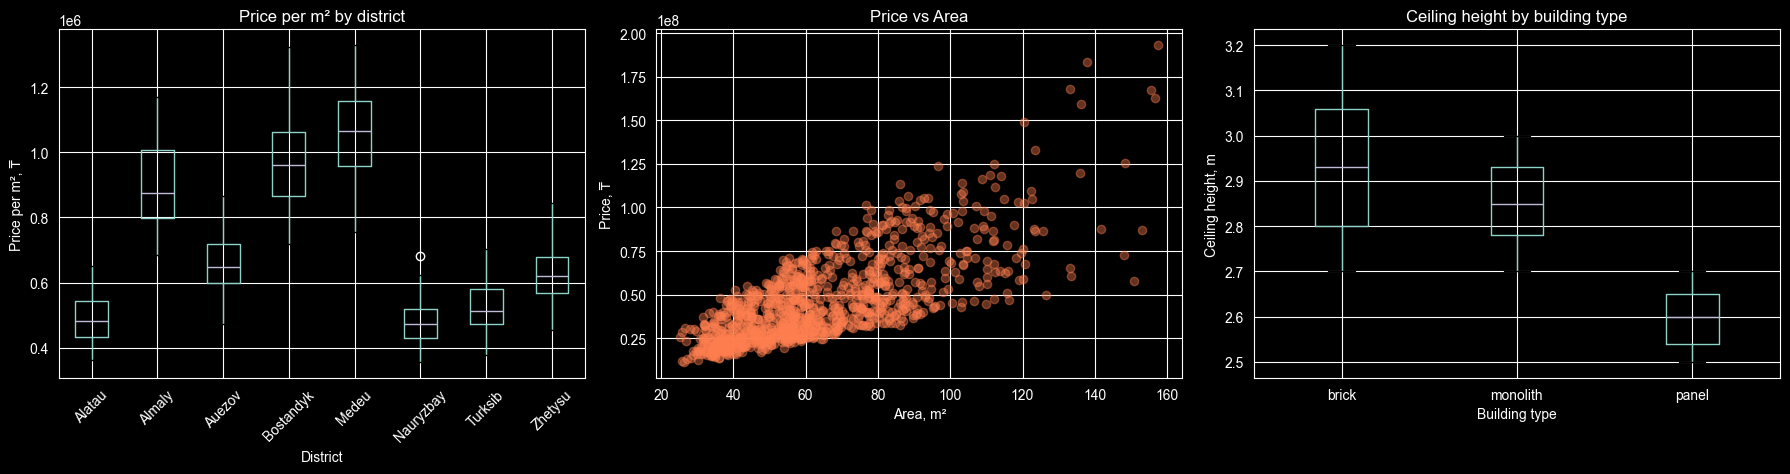

Наблюдение 1: медианная цена за м² в Medeu (1,064,399 ₸) в 2.25 раза выше, чем в Nauryzbay (473,034 ₸) -- самом дешёвом районе.
Наблюдение 2: корреляция площади и цены r = 0.74 -- связь сильная, но не идеальная, значит район и тип дома тоже вносят заметный вклад в цену.
Наблюдение 3: медианная высота потолков в панельных домах (2.60 м) на 0.33 м ниже, чем в кирпичных (2.93 м).


In [13]:
# Step 7: EDA -- три графика с числовым наблюдением под каждым
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) price_per_m2 by district
df_clean.boxplot(column="price_per_m2", by="district", rot=45, ax=axes[0])
axes[0].set_title("Price per m² by district")
axes[0].set_xlabel("District")
axes[0].set_ylabel("Price per m², ₸")

# 2) price vs area
axes[1].scatter(df_clean["area_m2"], df_clean["price_kzt"], alpha=0.4, color="coral")
axes[1].set_title("Price vs Area")
axes[1].set_xlabel("Area, m²")
axes[1].set_ylabel("Price, ₸")

# 3) ceiling height by building_type
df_clean.boxplot(column="ceiling_height_m", by="building_type", ax=axes[2])
axes[2].set_title("Ceiling height by building type")
axes[2].set_xlabel("Building type")
axes[2].set_ylabel("Ceiling height, m")

plt.suptitle("")
plt.tight_layout()
plt.show()

med_by_district = df_clean.groupby("district")["price_per_m2"].median().sort_values()
corr = df_clean["area_m2"].corr(df_clean["price_kzt"])
ceil_by_type = df_clean.groupby("building_type")["ceiling_height_m"].median()

print(f"Наблюдение 1: медианная цена за м² в Medeu ({med_by_district.iloc[-1]:,.0f} ₸) "
      f"в {med_by_district.iloc[-1] / med_by_district.iloc[0]:.2f} раза выше, чем в Nauryzbay "
      f"({med_by_district.iloc[0]:,.0f} ₸) -- самом дешёвом районе.")
print(f"Наблюдение 2: корреляция площади и цены r = {corr:.2f} -- связь сильная, но не идеальная, "
      f"значит район и тип дома тоже вносят заметный вклад в цену.")
print(f"Наблюдение 3: медианная высота потолков в панельных домах ({ceil_by_type['panel']:.2f} м) "
      f"на {ceil_by_type['brick'] - ceil_by_type['panel']:.2f} м ниже, чем в кирпичных "
      f"({ceil_by_type['brick']:.2f} м).")

In [14]:
# Итоговый cleaning log за Steps 3-4
log_df = pd.DataFrame(cleaning_log)
print(log_df.to_string(index=False))

import os
print("\nФайл data/almaty_apartments_clean.csv существует:",
      os.path.exists("data/almaty_apartments_clean.csv"))

Step                                                     Operation  Rows before  Rows after  Cells changed
  3a                                    Удаление точных дубликатов         1152        1123             29
  3a                  Репосты -> оставлен самый свежий listed_date         1123        1080             43
  3b                Нормализация district к 8 каноническим районам         1080        1080              0
  3c                       Парсинг rooms/area_m2/price_kzt в числа         1080        1080              0
   4 Сентинелы -> NaN (floor/-1, year_built/0, ceiling_height_m/0)         1080        1080             56
   4                             floor > total_floors -> floor=NaN         1080        1080             12
   4                            Выбросы price_per_m2: area_m2 / 10         1080        1080             11

Файл data/almaty_apartments_clean.csv существует: True
